In [2]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
trans = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

print("NAV Shape:", nav.shape)
print("Transactions Shape:", trans.shape)
print("Performance Shape:", perf.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 19)


In [3]:
print(nav.head())

print("\n")
print(trans.head())

print("\n")
print(perf.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30

In [4]:
nav.info()

print("\n-----------------\n")

trans.info()

print("\n-----------------\n")

perf.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB

-----------------

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-nu

In [5]:
print("Missing Values in NAV:")
print(nav.isnull().sum())

print("\nMissing Values in Transactions:")
print(trans.isnull().sum())

print("\nMissing Values in Performance:")
print(perf.isnull().sum())

Missing Values in NAV:
amfi_code    0
date         0
nav          0
dtype: int64

Missing Values in Transactions:
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

Missing Values in Performance:
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64


In [6]:
print(trans["transaction_type"].value_counts())

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


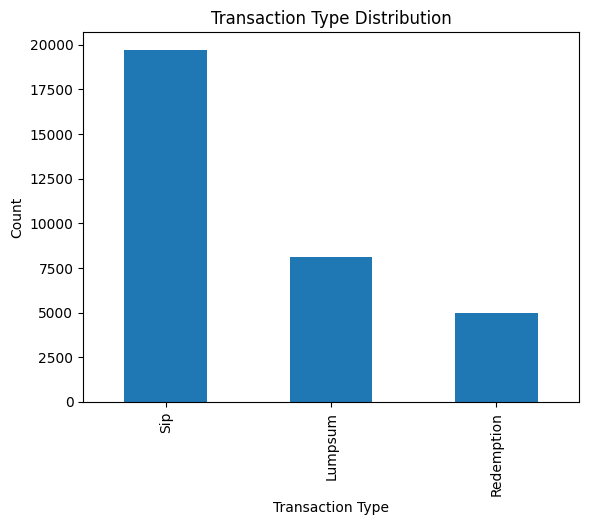

In [7]:
import matplotlib.pyplot as plt

trans["transaction_type"].value_counts().plot(kind="bar")

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [8]:
perf[["return_1yr_pct","return_3yr_pct","return_5yr_pct"]].describe()

,return_1yr_pct,return_3yr_pct,return_5yr_pct
count,40.000000,40.000000,40.000000
mean,14.376000,14.089000,14.516750
std,4.883023,4.617253,4.454021
min,4.260000,5.140000,5.430000
25%,11.735000,12.035000,12.340000
50%,14.620000,14.205000,14.185000
75%,16.392500,15.882500,17.585000
max,24.930000,23.390000,23.800000


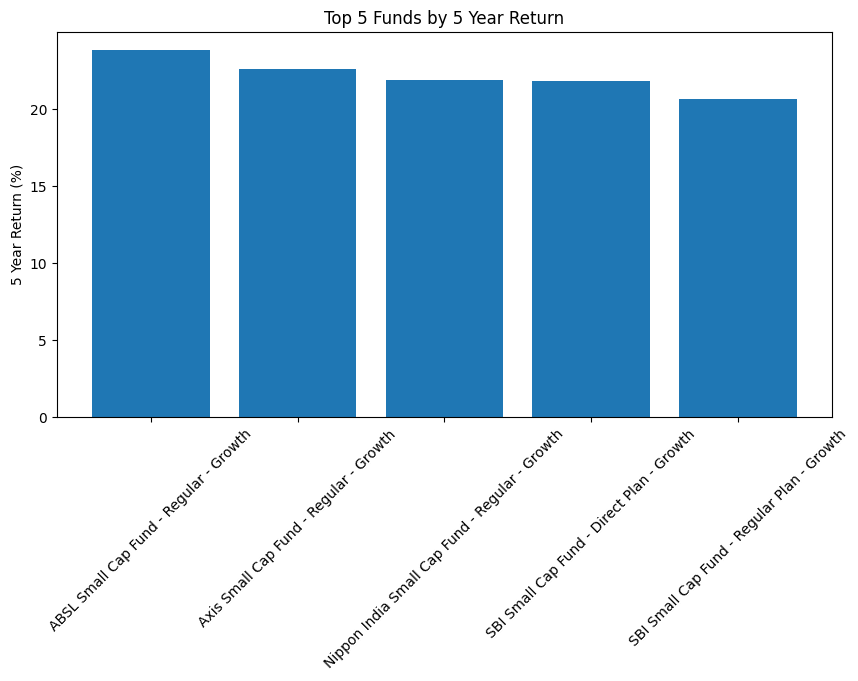

In [9]:
top5 = perf.sort_values("return_5yr_pct", ascending=False).head(5)

plt.figure(figsize=(10,5))
plt.bar(top5["scheme_name"], top5["return_5yr_pct"])
plt.title("Top 5 Funds by 5 Year Return")
plt.ylabel("5 Year Return (%)")
plt.xticks(rotation=45)
plt.show()

In [10]:
trans.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

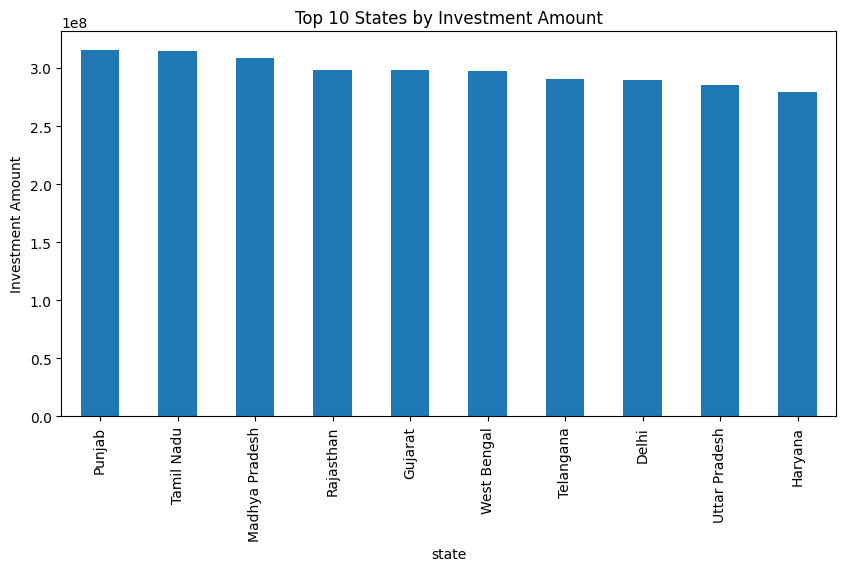

In [11]:
import matplotlib.pyplot as plt

top_states = trans.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")
plt.title("Top 10 States by Investment Amount")
plt.ylabel("Investment Amount")
plt.show()

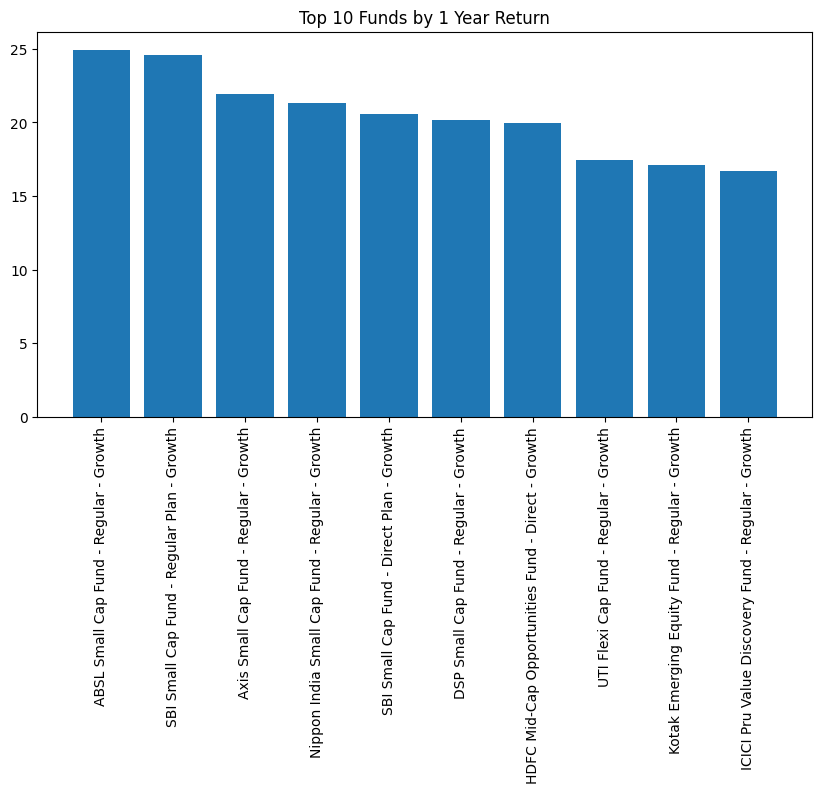

In [12]:
top_funds = perf.sort_values("return_1yr_pct", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_funds["scheme_name"], top_funds["return_1yr_pct"])
plt.title("Top 10 Funds by 1 Year Return")
plt.xticks(rotation=90)
plt.show()